In [ ]:
!pip install ultralytics

In [ ]:
!pip install opencv-python torch torchvision albumentations

In [ ]:
from ultralytics import YOLO
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import cv2
import zipfile
import tarfile
import os
import pandas as pd
import json
import yaml
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# def afficher_segmentation_yolo(modele_path: str, image_path: str):
#     """
#     Charge un modèle YOLOv8 de type segmentation, effectue une prédiction sur l'image,
#     puis affiche l'image avec les masques de segmentation.

#     Args:
#         modele_path (str): Chemin vers le modèle YOLOv8 (./).
#         image_path (str): Chemin vers l'image à analyser.
#     """
#     # Charger le modèle
#     model = YOLO(modele_path)

#     # Prédiction
#     results = model(image_path)
#     result = results[0]

#     # Générer l'image avec les masques
#     output_image = result.plot()
#     output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

#     # Afficher
#     plt.figure(figsize=(10, 10))
#     plt.imshow(output_image_rgb)
#     plt.axis('off')
#     plt.title("Masques de segmentation YOLOv8")
#     plt.show()

In [ ]:
# # Exemple d'utilisation
# afficher_segmentation_yolo(
#     modele_path="C:/Users/fanch/OneDrive/Bureau/Data_science/01_Jedha/Projets/Projet_final/dataset_jej_unzip_v2/model/calcul/best (1).pt",
#     image_path="C:/Users/fanch/OneDrive/Bureau/Data_science/01_Jedha/Projets/Projet_final/dataset_jej_unzip_v2/model/calcul/00005858.jpg",
#     )

### DEBUT MODEL

In [ ]:
import cv2
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO

def segmenter_et_calculer_aires_v5(model_path: str, image_path: str, yaml_path: str):
    """
    YOLOv8-seg : affiche l'image originale + image avec masques,
    retourne aussi le DataFrame avec :
    - class_id, label, area_pixels, percent_total, confidence
    """
    # Charger les noms de classes depuis le YAML
    with open(yaml_path, "r") as f:
        data_yaml = yaml.safe_load(f)
    class_names = data_yaml.get("names", {})

    # Charger le modèle
    model = YOLO(model_path)

    # Charger et préparer l'image d'origine
    original_bgr = cv2.imread(image_path)
    if original_bgr is None:
        raise FileNotFoundError(f"Image non trouvée : {image_path}")
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    # Prédiction
    results = model(image_path)
    result = results[0]

    # Image annotée (masques + boxes)
    output_image = result.plot()
    output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

    # Affichage : original + annoté
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output_image_rgb)
    plt.title("Segmentation YOLOv8")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Aucun masque détecté
    if result.masks is None:
        df = pd.DataFrame(columns=["class_id", "label", "area_pixels", "percent_total", "confidence"])
        return output_image_rgb, df

    masks = result.masks.data.cpu().numpy()
    num_masks = masks.shape[0]

    total_area = 0
    mask_infos = []

    for i in range(num_masks):
        class_id = int(result.boxes.cls[i].item())
        if isinstance(class_names, list):
            label = class_names[class_id]
        else:
            label = class_names.get(class_id, f"class_{class_id}")

        mask = masks[i]
        mask_bin = (mask > 0.5).astype(np.uint8)
        area = int(mask_bin.sum())
        confidence = float(result.boxes.conf[i].item())
        total_area += area
        mask_infos.append((class_id, label, area, confidence))

    # Construire le DataFrame
    data = []
    for class_id, label, area, confidence in mask_infos:
        percent = (area / total_area) * 100 if total_area > 0 else 0
        data.append({
            "class_id": class_id,
            "label": label,
            "area_pixels": area,
            "percent_total": round(percent, 2),
            "confidence": round(confidence, 3)
        })

    df = pd.DataFrame(data)

    return output_image_rgb, df


In [ ]:
def enrichir_avec_poids(df_yolo: pd.DataFrame, estimator: float = 500):
    """
    Calcule le poids estimé de chaque aliment en fonction du pourcentage de surface.

    Args:
        df_yolo (pd.DataFrame): DataFrame YOLOv8 contenant `label` et `percent_total`
        estimator (float): Poids total estimé de l’assiette (en grammes)

    Returns:
        tuple:
            - liste des labels détectés
            - DataFrame enrichi avec une colonne `poids` (en grammes)
    """
    # 1. Extraire les labels
    labels_detectes = df_yolo["label"].tolist()

    # 2. Calcul du poids estimé
    df_yolo = df_yolo.copy()
    df_yolo["poids"] = (df_yolo["percent_total"] / 100) * estimator
    df_yolo["poids"] = df_yolo["poids"].round(1)

    return labels_detectes, df_yolo


Mounted at /content/drive

image 1/1 /content/drive/My Drive/Calcul/images/test/00005817.jpg: 640x640 1 chicken duck, 2 tomatos, 1 lettuce, 7703.5ms
Speed: 3.7ms preprocess, 7703.5ms inference, 70.8ms postprocess per image at shape (1, 3, 640, 640)


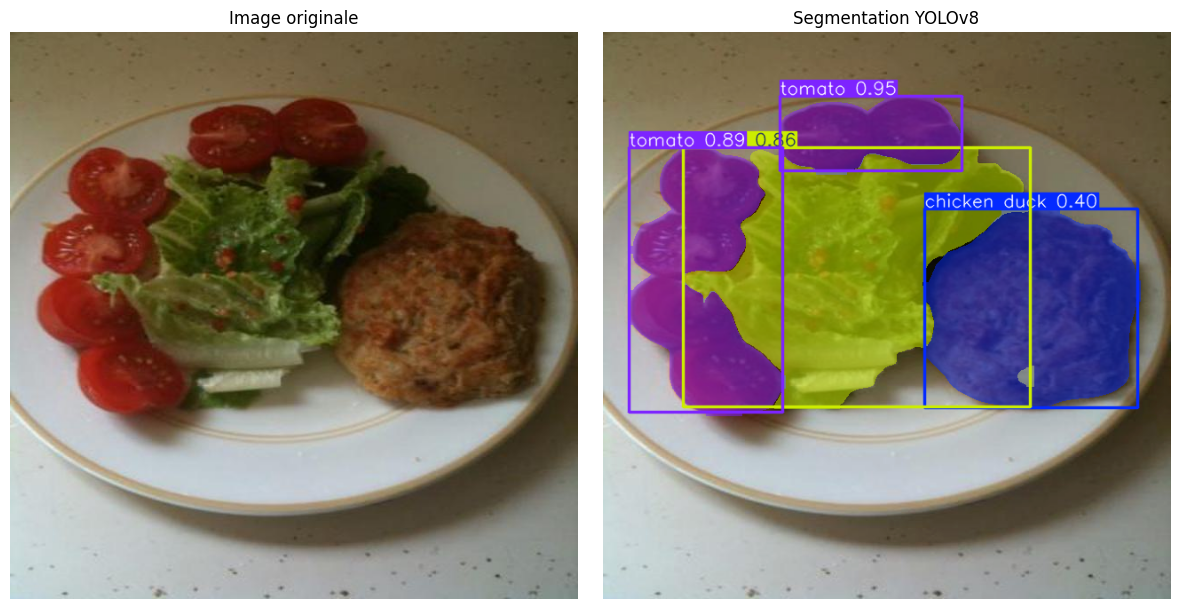

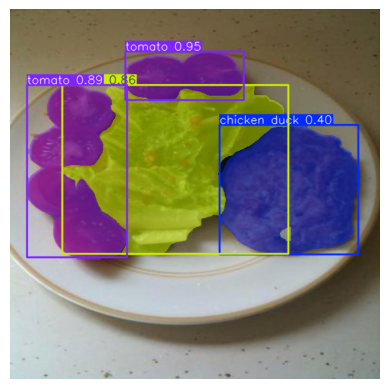

   class_id         label  area_pixels  percent_total  confidence
0        15        tomato        13713           9.14       0.955
1        15        tomato        31226          20.82       0.886
2        27       lettuce        61717          41.15       0.856
3         0  chicken duck        43316          28.88       0.403


In [ ]:
from google.colab import drive
import matplotlib.pyplot as plt

# Monter Google Drive
drive.mount('/content/drive')

# Exécuter la fonction avec les chemins corrects
img, df_yolo = segmenter_et_calculer_aires_v5(
    model_path="/content/drive/My Drive/final_project/yolov8x-seg-finetune-freeze-last3/weights/best.pt",  # Chemin du modèle
    image_path="/content/drive/My Drive/Calcul/images/test/00005817.jpg",  # Chemin de l'image
    yaml_path="/content/drive/My Drive/final_project/yolo_v3.yaml"  # Chemin du fichier .yaml
)

# Afficher l'image segmentée
plt.imshow(img)
plt.axis("off")
plt.show()

# Afficher le dataframe des résultats YOLO
print(df_yolo)





In [ ]:
labels, df_enrichi = enrichir_avec_poids(df_yolo, estimator=300)

print("Labels détectés :", labels)
print(df_enrichi)


Labels détectés : ['tomato', 'tomato', 'lettuce', 'chicken duck']
   class_id         label  area_pixels  percent_total  confidence  poids
0        15        tomato        13713           9.14       0.955   27.4
1        15        tomato        31226          20.82       0.886   62.5
2        27       lettuce        61717          41.15       0.856  123.4
3         0  chicken duck        43316          28.88       0.403   86.6


In [ ]:
print(labels)


['tomato', 'tomato', 'lettuce', 'chicken duck']


In [ ]:
import requests
import time

# Clé API DeepL
API_KEY = "c5e1624a-2cc8-4333-9143-2c3374ca0145:fx"
DEEPL_URL = "https://api-free.deepl.com/v2/translate"

def traduire_liste_avec_deepl(liste_mots, source_lang="EN", target_lang="FR", sleep_time=1.2):
    """
    Traduit une liste de mots avec DeepL et retourne une liste de traductions.

    Args:
        liste_mots (list): liste de mots ou expressions à traduire
        source_lang (str): langue source (ex: 'EN')
        target_lang (str): langue cible (ex: 'FR')
        sleep_time (float): pause entre les requêtes pour respecter l'API

    Returns:
        list: liste des mots traduits dans le même ordre
    """
    liste_traductions = []

    for i, mot in enumerate(liste_mots):
        if mot:
            print(f"Traduction {i+1}/{len(liste_mots)} : {mot}")
            response = requests.post(
                DEEPL_URL,
                data={
                    "auth_key": API_KEY,
                    "text": mot,
                    "source_lang": source_lang,
                    "target_lang": target_lang
                }
            )
            if response.status_code == 200:
                traduit = response.json()["translations"][0]["text"]
            else:
                print(f"❌ Erreur pour '{mot}':", response.text)
                traduit = None

            liste_traductions.append(traduit)
            time.sleep(sleep_time)

    return liste_traductions


labels_en = labels
labels_fr = traduire_liste_avec_deepl(labels_en)

print("Traductions :", labels_fr)

Traduction 1/4 : tomato
Traduction 2/4 : tomato
Traduction 3/4 : lettuce
Traduction 4/4 : chicken duck
Traductions : ['tomate', 'tomate', 'laitue', 'poulet canard']


In [ ]:
from sentence_transformers import SentenceTransformer
from tensorflow import keras

model = SentenceTransformer("all-MiniLM-L6-v2")

labels_embeddings = model.encode(labels_fr)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
labels_embeddings #labels en sortie du model YOLO après l'embedding

array([[   -0.10211,    0.053491,    0.059844, ...,   -0.023391,    0.065494,   -0.047075],
       [   -0.10211,    0.053491,    0.059844, ...,   -0.023391,    0.065494,   -0.047075],
       [ 0.00070492,   -0.028316,    -0.02206, ...,  -0.0024828,    0.068133,    0.020344],
       [  -0.027045,    0.048775,   -0.095074, ...,   -0.017917,    0.077502,    0.068521]], dtype=float32)

In [ ]:
# Ajouter les embeddings comme une nouvelle colonne
df_enrichi['embedding'] = list(labels_embeddings)

# Afficher le DataFrame avec les embeddings ajoutés
print(df_enrichi)

   class_id         label  area_pixels  percent_total  confidence  poids  \
0        15        tomato        13713           9.14       0.955   27.4   
1        15        tomato        31226          20.82       0.886   62.5   
2        27       lettuce        61717          41.15       0.856  123.4   
3         0  chicken duck        43316          28.88       0.403   86.6   

                                           embedding  
0  [-0.10211021, 0.05349111, 0.059844162, -0.0771...  
1  [-0.10211021, 0.05349111, 0.059844162, -0.0771...  
2  [0.000704925, -0.028316177, -0.022059957, 0.01...  
3  [-0.027044738, 0.048774816, -0.09507357, -0.07...  


In [ ]:
# Mettre à jour le chemin du fichier CSV
ig_table = pd.read_csv('/content/drive/My Drive/final_project/ig_table.csv')

# Afficher les premières lignes du dataframe
ig_table.head()


,Aliment,IG
0,abricot frais,30.0
1,abricot sec,35.0
2,abricot au sirop,55.0
3,ail,30.0
4,airelle rouge,45.0


In [ ]:
aliment_to_embed = [ch for ch in ig_table['Aliment']]
aliment_to_embed[:15]

['abricot frais',
 'abricot sec',
 'abricot au sirop',
 'ail',
 'airelle rouge',
 'amande',
 'ananas frais',
 'ananas au sirop',
 'arachide',
 'artichaut',
 'asperge',
 'aubergine',
 'avocat',
 'banane verte',
 'banane mûre']

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings_aliments = model.encode(aliment_to_embed)
embeddings_aliments[:15] #embeddings de la table ig_table

array([[  -0.096728,  -0.0068154,   -0.047541, ...,    0.030809,    0.074584,   -0.021836],
       [  -0.098149,   -0.027547,   -0.053424, ...,   -0.015224,    0.011865,   -0.050249],
       [ -0.0038608,    0.021107,   -0.055518, ...,    0.015749,    0.021455,   -0.028774],
       ...,
       [  -0.041413,   0.0041799,    -0.03943, ...,   -0.053531,     0.02628,     0.12832],
       [  0.0036822,    0.046994,    -0.12411, ...,    0.034302,    0.023113,    -0.11361],
       [  -0.049294,   0.0020107,   -0.022875, ...,   -0.054103,   0.0074296,   -0.084822]], dtype=float32)

In [ ]:
ig_table['aliments_embedding'] = embeddings_aliments.tolist()
ig_table.head()

,Aliment,IG,aliments_embedding
0,abricot frais,30.0,"[-0.09672834724187851, -0.006815427914261818, ..."
1,abricot sec,35.0,"[-0.09814923256635666, -0.027547087520360947, ..."
2,abricot au sirop,55.0,"[-0.0038607700262218714, 0.02110731229186058, ..."
3,ail,30.0,"[-0.09047166258096695, 0.015997514128684998, 0..."
4,airelle rouge,45.0,"[-0.006428626831620932, -0.058962300419807434,..."


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Extraction des embeddings
embeddings1 = np.stack(df_enrichi['embedding'].values)
embeddings2 = np.stack(ig_table['aliments_embedding'].values)

# Calcul des similarités cosinus
similarities = cosine_similarity(embeddings1, embeddings2)

# Trouver le meilleur match pour chaque aliment de df1
matched_indices = np.argmax(similarities, axis=1)
df_enrichi['index_glycemique'] = ig_table.iloc[matched_indices]['IG'].values

# Affichage du résultat
print(df_enrichi[['label', 'poids', 'percent_total', 'confidence', 'index_glycemique']])

          label  poids  percent_total  confidence  index_glycemique
0        tomato   27.4           9.14       0.955              30.0
1        tomato   62.5          20.82       0.886              30.0
2       lettuce  123.4          41.15       0.856              30.0
3  chicken duck   86.6          28.88       0.403               0.0


In [ ]:
df_enrichi['nbre_glucides'] = (df_enrichi['poids']*df_enrichi['index_glycemique']) / 100
df_enrichi.head()

,class_id,label,area_pixels,percent_total,confidence,poids,embedding,index_glycemique,nbre_glucides
0,15,tomato,13713,9.14,0.955,27.4,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,8.22
1,15,tomato,31226,20.82,0.886,62.5,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,18.75
2,27,lettuce,61717,41.15,0.856,123.4,"[0.000704925, -0.028316177, -0.022059957, 0.01...",30.0,37.02
3,0,chicken duck,43316,28.88,0.403,86.6,"[-0.027044738, 0.048774816, -0.09507357, -0.07...",0.0,0.00


In [ ]:
# A DEPLACER POUR EXECUTER AVANT EMBEDDING SORTIE YOLO
df_enrichi['label_cooked'] = df_enrichi['label'] + " " + "cooked"
df_enrichi.head()

,class_id,label,area_pixels,percent_total,confidence,poids,embedding,index_glycemique,nbre_glucides,label_cooked
0,15,tomato,13713,9.14,0.955,27.4,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,8.22,tomato cooked
1,15,tomato,31226,20.82,0.886,62.5,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,18.75,tomato cooked
2,27,lettuce,61717,41.15,0.856,123.4,"[0.000704925, -0.028316177, -0.022059957, 0.01...",30.0,37.02,lettuce cooked
3,0,chicken duck,43316,28.88,0.403,86.6,"[-0.027044738, 0.048774816, -0.09507357, -0.07...",0.0,0.00,chicken duck cooked


In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np
# import pandas as pd

# def trouver_correspondances_avec_IG(labels_embeddings, ig_table, colonne_embedding="aliments_embedding", colonne_ig="IG"):
#     """
#     Pour chaque vecteur, retourne l'index de la ligne la plus similaire du DataFrame,
#     le score de similarité, et la valeur de IG correspondante.

#     Args:
#         labels_embeddings (list of np.array): liste de vecteurs d'entrée
#         ig_table (pd.DataFrame): DataFrame contenant les colonnes d'embedding et IG
#         colonne_embedding (str): nom de la colonne contenant les embeddings
#         colonne_ig (str): nom de la colonne IG dans le DataFrame

#     Returns:
#         list of dicts: [
#             {
#                 'input_index': i,
#                 'best_match_index': index dans df,
#                 'similarity': score,
#                 'IG': valeur correspondante
#             }, ...
#         ]
#     """
#     resultats = []

#     # Conversion en matrice numpy
#     matrice_df = np.vstack(ig_table[colonne_embedding].values)

#     for i, vec in enumerate(labels_embeddings):
#         vec = np.array(vec).reshape(1, -1)
#         scores = cosine_similarity(vec, matrice_df)[0]
#         idx_max = np.argmax(scores)
#         score_max = scores[idx_max]

#         index_df = ig_table.index[idx_max]
#         ig_value = ig_table.loc[index_df, colonne_ig] if colonne_ig in ig_table.columns else None

#         resultats.append({
#             "input_index": i,
#             "best_match_index": index_df,
#             "similarity": round(score_max, 4),
#             "IG": ig_value
#         })

#     return resultats

In [ ]:
# correspondances = trouver_correspondances_avec_IG(labels_embeddings, ig_table)

# for match in correspondances:
#     print(f"🔍 Vecteur {match['input_index']} → ligne {match['best_match_index']}, IG = {match['IG']}, similarité = {match['similarity']}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from ultralytics import YOLO
import os
import pandas as pd
from tqdm import tqdm  # Affichage de la progression

# 💾 Charger les modèles
model_1 = YOLO("/content/drive/My Drive/best_model1.pt")
model_2 = YOLO("/content/drive/My Drive/best_model2.pt")


# 📁 Dossier contenant les images
image_folder = "/content/drive/My Drive/dataset_etalonne/"

# 📦 Liste pour stocker les résultats
results_list = []

# 📂 Liste des images à traiter
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 🔁 Parcourir les images avec barre de progression
for img_name in tqdm(image_files, desc="🔍 Analyse des images"):
    image_path = os.path.join(image_folder, img_name)

    # 🔁 Prédiction avec les deux modèles
    for model_idx, model in enumerate([model_1, model_2], start=1):
        try:
            results = model(image_path)

            for result in results:
                # 🎯 Si masques disponibles
                if result.masks is not None:
                    masks = result.masks.data.cpu().numpy()
                    areas = [int(mask.sum()) for mask in masks]
                else:
                    areas = [None] * len(result.boxes)

                # 📦 Infos sur chaque objet détecté
                for i, box in enumerate(result.boxes):
                    label = result.names[int(box.cls)]
                    conf = float(box.conf)
                    area_mask = areas[i]

                    results_list.append({
                        "image": img_name,
                        "model": f"model{model_idx}",
                        "label": label,
                        "confidence": conf,
                        "segmentation_area_pixels": area_mask
                    })

        except Exception as e:
            print(f"⚠️ Erreur avec l'image {img_name} pour le modèle {model_idx}: {e}")

# 🧾 Convertir en DataFrame
df_results = pd.DataFrame(results_list)

# 👀 Aperçu des résultats
print("✅ Résultats extraits :")
df_results.head()





🔍 Analyse des images:   0%|          | 0/37 [00:00<?, ?it/s]


image 1/1 /content/drive/My Drive/dataset_etalonne/20250406_105312.jpg: 640x480 1 fork, 1 rice, 8888.7ms
Speed: 46.7ms preprocess, 8888.7ms inference, 12.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/My Drive/dataset_etalonne/20250406_105312.jpg: 640x480 1 fork, 1 class_ass_195, 1816.6ms
Speed: 4.4ms preprocess, 1816.6ms inference, 12.6ms postprocess per image at shape (1, 3, 640, 480)


🔍 Analyse des images:   3%|▎         | 1/37 [00:17<10:34, 17.63s/it]


image 1/1 /content/drive/My Drive/dataset_etalonne/20250406_105314.jpg: 640x480 1 fork, 1 rice, 5093.0ms
Speed: 5.8ms preprocess, 5093.0ms inference, 10.8ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/My Drive/dataset_etalonne/20250406_105314.jpg: 640x480 1 fork, 1 class_ass_195, 1507.7ms
Speed: 4.3ms preprocess, 1507.7ms inference, 8.1ms postprocess per image at shape (1, 3, 640, 480)


🔍 Analyse des images:   5%|▌         | 2/37 [00:25<06:53, 11.82s/it]

...

🔍 Analyse des images:  97%|█████████▋| 36/37 [04:46<00:07,  7.40s/it]


image 1/1 /content/drive/My Drive/dataset_etalonne/20250406_110040.jpg: 480x640 1 fork, 1 rice, 1 potato, 4253.4ms
Speed: 4.5ms preprocess, 4253.4ms inference, 16.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/drive/My Drive/dataset_etalonne/20250406_110040.jpg: 480x640 1 fork, 1 class_ass_195, 1 class_ass_270, 1484.6ms
Speed: 4.3ms preprocess, 1484.6ms inference, 16.1ms postprocess per image at shape (1, 3, 480, 640)


🔍 Analyse des images: 100%|██████████| 37/37 [04:53<00:00,  7.92s/it]

✅ Résultats extraits :


,image,model,label,confidence,segmentation_area_pixels
0,20250406_105312.jpg,model1,fork,0.972640,7829
1,20250406_105312.jpg,model1,rice,0.788845,31311
2,20250406_105312.jpg,model2,class_ass_195,0.983689,76684
3,20250406_105312.jpg,model2,fork,0.947873,5478
4,20250406_105314.jpg,model1,fork,0.980919,6804


In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)  # Affiche toutes les lignes
pd.set_option('display.max_columns', None)  # (optionnel) Affiche toutes les colonnes

print(df_results)

                   image   model          label  confidence  \
0    20250406_105312.jpg  model1           fork    0.972640   
1    20250406_105312.jpg  model1           rice    0.788845   
2    20250406_105312.jpg  model2  class_ass_195    0.983689   
3    20250406_105312.jpg  model2           fork    0.947873   
4    20250406_105314.jpg  model1           fork    0.980919   
5    20250406_105314.jpg  model1           rice    0.827464   
6    20250406_105314.jpg  model2  class_ass_195    0.987385   
7    20250406_105314.jpg  model2           fork    0.951575   
8    20250406_105317.jpg  model1           fork    0.987722   
9    20250406_105317.jpg  model2  class_ass_195    0.986270   
10   20250406_105317.jpg  model2           fork    0.931634   
11   20250406_105325.jpg  model1           fork    0.990511   
12   20250406_105325.jpg  model1           rice    0.703418   
13   20250406_105325.jpg  model2  class_ass_195    0.978441   
14   20250406_105325.jpg  model2           fork    0.97

In [ ]:
# 🧹 Supprimer les lignes où la colonne 'label' contient le mot "fork"
df_cleaned = df_results[~df_results['label'].str.contains("fork", case=False)]
df_cleaned


,image,model,label,confidence,segmentation_area_pixels
1,20250406_105312.jpg,model1,rice,0.788845,31311
2,20250406_105312.jpg,model2,class_ass_195,0.983689,76684
5,20250406_105314.jpg,model1,rice,0.827464,26787
6,20250406_105314.jpg,model2,class_ass_195,0.987385,67970
9,20250406_105317.jpg,model2,class_ass_195,0.986270,109150
12,20250406_105325.jpg,model1,rice,0.703418,25707
13,20250406_105325.jpg,model2,class_ass_195,0.978441,70464
15,20250406_105325.jpg,model2,class_ass_195,0.259616,66243
17,20250406_105331.jpg,model1,rice,0.657306,25278
18,20250406_105331.jpg,model2,class_ass_195,0.986657,69567


In [ ]:
# 📋 Liste des labels uniques détectés
unique_labels = df_cleaned['label'].unique()

print("🧾 Labels détectés dans les résultats :")
for label in unique_labels:
    print("-", label)


🧾 Labels détectés dans les résultats :
- rice
- class_ass_195
- potato
- green beans
- pasta
- class_ass_270
- shrimp


In [ ]:
# 📊 Moyenne de la surface de chaque aliment détecté
mean_area_per_label = df_cleaned.groupby('label')['segmentation_area_pixels'].mean().reset_index()
# 🖨️ Afficher le résultat
print("🍽️ Moyenne des surfaces (en pixels) par aliment détecté :")
print(mean_area_per_label)


🍽️ Moyenne des surfaces (en pixels) par aliment détecté :
           label  segmentation_area_pixels
0  class_ass_195              67127.923077
1  class_ass_270              86888.333333
2    green beans              27870.272727
3          pasta              25599.000000
4         potato              25934.875000
5           rice              19033.352941
6         shrimp              23140.000000


In [ ]:
# 👉 Recalculer la moyenne des surfaces par aliment
mean_area_per_label = df_cleaned.groupby('label')['segmentation_area_pixels'].mean().reset_index()
mean_area_per_label.rename(columns={'segmentation_area_pixels': 'mean_area'}, inplace=True)

# 🔗 Fusionner les moyennes avec df_cleaned
df_with_mean = pd.merge(df_cleaned, mean_area_per_label, on='label', how='left')

# ⚖️ Calculer le "poids estimé" basé sur l'aire
df_with_mean['poids'] = (df_with_mean['segmentation_area_pixels'] / df_with_mean['mean_area']) * 100

# 👀 Afficher le résultat
df_with_mean[['image', 'label', 'segmentation_area_pixels', 'mean_area', 'poids']].head()



,image,label,segmentation_area_pixels,mean_area,poids
0,20250406_105312.jpg,rice,31311,19033.352941,164.505960
1,20250406_105312.jpg,class_ass_195,76684,67127.923077,114.235621
2,20250406_105314.jpg,rice,26787,19033.352941,140.737158
3,20250406_105314.jpg,class_ass_195,67970,67127.923077,101.254436
4,20250406_105317.jpg,class_ass_195,109150,67127.923077,162.599996


In [ ]:
# Supprimer toutes les lignes où 'label' contient 'class_ass'
df_cleaned = df_with_mean[~df_with_mean['label'].str.contains("class_ass", case=False, na=False)]
df_cleaned.head()


,image,model,label,confidence,segmentation_area_pixels,mean_area,poids
0,20250406_105312.jpg,model1,rice,0.788845,31311,19033.352941,164.505960
2,20250406_105314.jpg,model1,rice,0.827464,26787,19033.352941,140.737158
5,20250406_105325.jpg,model1,rice,0.703418,25707,19033.352941,135.062908
8,20250406_105331.jpg,model1,rice,0.657306,25278,19033.352941,132.808970
10,20250406_105411.jpg,model1,potato,0.903751,17177,25934.875000,66.231281


In [ ]:
df_cleaned["difference_poids"] = df_cleaned["poids"] - 100
df_cleaned.head()

<ipython-input-53-cb97a33ff1b0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["difference_poids"] = df_cleaned["poids"] - 100


,image,model,label,confidence,segmentation_area_pixels,mean_area,poids,difference_poids
0,20250406_105312.jpg,model1,rice,0.788845,31311,19033.352941,164.505960,64.505960
2,20250406_105314.jpg,model1,rice,0.827464,26787,19033.352941,140.737158,40.737158
5,20250406_105325.jpg,model1,rice,0.703418,25707,19033.352941,135.062908,35.062908
8,20250406_105331.jpg,model1,rice,0.657306,25278,19033.352941,132.808970,32.808970
10,20250406_105411.jpg,model1,potato,0.903751,17177,25934.875000,66.231281,-33.768719


In [ ]:
df_unique = df_with_mean.drop_duplicates(subset=['image', 'label'])


In [ ]:
mean_weight_per_label = df_unique.groupby('label')['poids'].mean().reset_index()
mean_weight_per_label.rename(columns={'poids': 'mean_poids'}, inplace=True)
mean_weight_per_label.head()



,label,mean_poids
0,class_ass_195,116.291
1,class_ass_270,100.000
2,green beans,100.000
3,pasta,100.000
4,potato,100.000


In [ ]:
import yaml

yaml_path = "/content/drive/My Drive/data_update.yaml"  # 🔁 Remplace par ton chemin

try:
    # ✅ Charger le fichier YAML
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    # Vérification de la présence de la clé 'names' avant de l'utiliser
    if 'names' in data:
        # ✅ Extraire les noms
        class_names = list(data['names'].values())
        assiette_classes = [name for name in class_names if 'class_ass' in name]

        print("✅ Classes d’assiettes trouvées :", assiette_classes)
    else:
        print("❌ La clé 'names' est absente dans le fichier YAML.")
except FileNotFoundError:
    print(f"❌ Le fichier YAML à l'emplacement {yaml_path} n'a pas été trouvé.")
except yaml.YAMLError as e:
    print(f"❌ Erreur lors de la lecture du fichier YAML : {e}")



❌ Le fichier YAML à l'emplacement /content/drive/My Drive/data_update.yaml n'a pas été trouvé.


In [ ]:
# 👉 Identifier les assiettes dans les images
df_assiettes = df_cleaned[df_cleaned['label'].str.contains('class_ass', case=False)]
df_assiettes = df_assiettes[['image', 'segmentation_area_pixels']].rename(columns={'segmentation_area_pixels': 'pixels_assiette'})

# 👉 Fusion avec le DataFrame principal
df_class_ass = pd.merge(df_cleaned, df_assiettes, on='image', how='left')

# 👉 Calcul de la proportion (class_ass)
df_class_ass['class_ass'] = df_class_ass['segmentation_area_pixels'] / df_class_ass['pixels_assiette']



# 👀 Aperçu
df_class_ass[['image', 'label', 'segmentation_area_pixels', 'pixels_assiette', 'class_ass']].head()


,image,label,segmentation_area_pixels,pixels_assiette,class_ass
0,20250406_105312.jpg,rice,31311,NaN,NaN
1,20250406_105314.jpg,rice,26787,NaN,NaN
2,20250406_105325.jpg,rice,25707,NaN,NaN
3,20250406_105331.jpg,rice,25278,NaN,NaN
4,20250406_105411.jpg,potato,17177,NaN,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_path = "/content/drive/My Drive/eval/"
print("Contenu du dossier :", os.listdir(test_path))


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/eval/'

In [ ]:
from ultralytics import YOLO
import os
import pandas as pd
from tqdm import tqdm

# 📁 Monter Google Drive (si ce n'est pas déjà fait)
from google.colab import drive
drive.mount('/content/drive')

# 💾 Charger le modèle
model_1 = YOLO("/content/drive/My Drive/best_model1.pt")

# 📁 Dossier contenant les images
image_folder = "/content/drive/My Drive/eval/sample_im/"

# Vérifie que le dossier existe
if not os.path.exists(image_folder):
    raise FileNotFoundError(f"📂 Le dossier spécifié n'existe pas : {image_folder}")

# 📦 Liste pour stocker les résultats
results_list = []

# 📂 Liste des images à traiter
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 🔁 Parcourir les images avec barre de progression
for img_name in tqdm(image_files, desc="🔍 Analyse des images"):
    image_path = os.path.join(image_folder, img_name)

    try:
        results = model_1(image_path)

        for result in results:
            # 🎯 Si masques disponibles
            if result.masks is not None:
                masks = result.masks.data.cpu().numpy()
                areas = [int(mask.sum()) for mask in masks]
            else:
                areas = [None] * len(result.boxes)

            # 📦 Infos sur chaque objet détecté
            for i, box in enumerate(result.boxes):
                label = result.names[int(box.cls)]
                conf = float(box.conf)
                area_mask = areas[i]

                results_list.append({
                    "image": img_name,
                    "model": "model1",
                    "label": label,
                    "confidence": conf,
                    "segmentation_area_pixels": area_mask
                })

    except Exception as e:
        print(f"⚠️ Erreur avec l'image {img_name} : {e}")

# 🧾 Convertir en DataFrame
df_results = pd.DataFrame(results_list)

# 👀 Aperçu des résultats
print("✅ Résultats extraits :")
print(df_results.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: 📂 Le dossier spécifié n'existe pas : /content/drive/My Drive/eval/sample_im/

In [ ]:
label_folder = "/content/drive/My Drive/Dataset_test/labels/"

df_results['label_path'] = df_results['image'].apply(lambda x: os.path.join(label_folder, x.replace('.jpg', '.txt')))
df_eval = df_results.groupby('image').agg({'label': list, 'label_path':'first'})
df_eval.head()

,label,label_path
image,,
00005239.jpg,"[pie, bread, steak]",/content/drive/My Drive/Dataset_test/labels/00...
00005240.jpg,"[carrot, french beans, steak, french fries, on...",/content/drive/My Drive/Dataset_test/labels/00...
00005241.jpg,"[carrot, lemon, potato, potato, shrimp]",/content/drive/My Drive/Dataset_test/labels/00...
00005242.jpg,"[broccoli, steak, pork]",/content/drive/My Drive/Dataset_test/labels/00...
00005243.jpg,"[cilantro mint, tomato, tomato, steak, tomato,...",/content/drive/My Drive/Dataset_test/labels/00...


In [ ]:

# ✅ Étape suivante : Lecture des labels ground truth et comparaison
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 📁 Dossier de labels ground truth
label_folder = "/content/drive/My Drive/Dataset_test/labels/"

In [ ]:
# 🏷️ Fonction pour lire les labels réels depuis les fichiers .txt
def get_label_from_txt(txt_path):
    labels = []
    with open(txt_path, 'r') as f:
        for line in f:
            class_id = int(line.strip().split()[0])
            labels.append(model_1.names[class_id])  # Tu peux utiliser model_2 aussi
    return labels


In [ ]:
# 📦 Liste des vrais labels (true labels)
true_data = []
for img_name in os.listdir(image_folder):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        label_path = os.path.join(label_folder, img_name.replace('.jpg', '.txt'))
        if os.path.exists(label_path):
            labels = get_label_from_txt(label_path)
            for lbl in labels:
                true_data.append({
                    "image": img_name,
                    "true_label": lbl
                })

df_true = pd.DataFrame(true_data)
df_true

""


In [ ]:
label_folder = "/content/drive/My Drive/Dataset_test/labels/"  # ✅ bien utilisé ici

# 🏷️ Lire les vrais labels depuis les fichiers .txt
def get_label_from_txt(txt_path):
    labels = []
    try:
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) > 0:
                    class_id = int(parts[0])
                    label = model_1.names[class_id]
                    labels.append(label)
    except FileNotFoundError:
        pass
    return labels

# 📦 Récupérer les vrais labels
true_data = []

for img_name in os.listdir(image_folder):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        label_path = os.path.join(label_folder, img_name.replace('.jpg', '.txt'))
        if os.path.exists(label_path):
            labels = get_label_from_txt(label_path)
            for lbl in labels:
                true_data.append({
                    "image": img_name,
                    "true_label": lbl,
                    "label_path": label_path
                })

df_true = pd.DataFrame(true_data)
print(f"✅ {len(df_true)} vrais labels trouvés")
print(df_true.head())

✅ 0 vrais labels trouvés
Empty DataFrame
Columns: []
Index: []


In [ ]:
# 👉 Suppose que df_results contient tes prédictions (via modèle 1 ou 2)
# Il doit contenir une colonne "label" (prédite) et "image"
df_pred = df_results[['image', 'label']].rename(columns={"label": "pred_label"})

df_pred

,image,pred_label
0,00005521.jpg,bread
1,00005521.jpg,steak
2,00005521.jpg,sausage
3,00005521.jpg,cucumber
4,00005553.jpg,cilantro mint
...,...,...
6684,00005550.jpg,shrimp
6685,00005550.jpg,cilantro mint
6686,00005550.jpg,tomato
6687,00005550.jpg,shrimp


In [ ]:
# 🔗 Fusionner les deux sur l'image (attention, plusieurs lignes par image possible)
df_eval = pd.merge(df_true, df_pred, on="image", how="inner")

KeyError: 'image'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

image 1/1 /content/drive/My Drive/Calcul/images/Sample/Copy of 00005816.jpg: 640x640 3 chicken ducks, 4 corns, 6228.6ms
Speed: 4.2ms preprocess, 6228.6ms inference, 32.8ms postprocess per image at shape (1, 3, 640, 640)


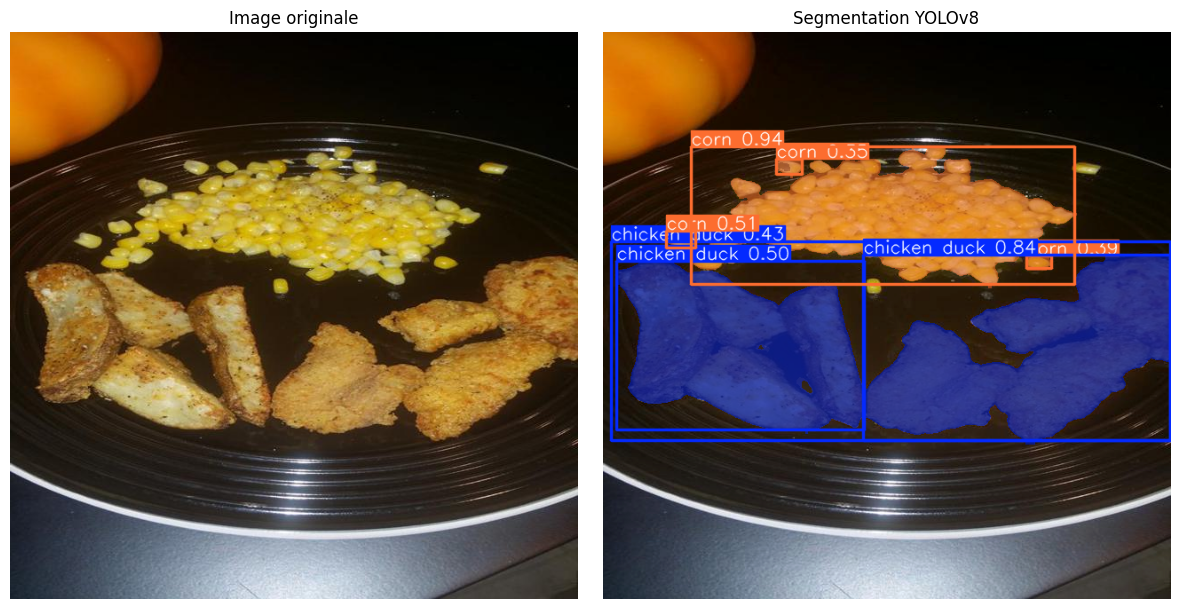

In [ ]:
from google.colab import drive
import matplotlib.pyplot as plt

# Monter Google Drive
drive.mount('/content/drive')

# Exécuter la fonction avec les chemins corrects
img, df_yolo = segmenter_et_calculer_aires_v5(
    model_path="/content/drive/My Drive/final_project/yolov8x-seg-finetune-freeze-last3/weights/best.pt",  # Chemin du modèle
    image_path="/content/drive/My Drive/Calcul/images/Sample/Copy of 00005816.jpg",  # Chemin de l'image
    yaml_path="/content/drive/My Drive/final_project/yolo_v3.yaml")  # Chemin du fichier .yaml